In [3]:
import pandas as pd

real = pd.read_csv("D:/SIT_764/TableGan/tableGAN/data/Adult/Adult.csv", sep=";")
fake = pd.read_csv("D:/SIT_764/TableGan/tableGAN/samples/Adult/Adult_OI_11_00_fake.csv", sep=";")

print("Real dataset shape:", real.shape)
print("Fake dataset shape:", fake.shape)

print("\n--- Real data summary ---")
print(real.describe())

print("\n--- Fake data summary ---")
print(fake.describe())


Real dataset shape: (2000, 14)
Fake dataset shape: (2000, 14)

--- Real data summary ---
               age    workclass        fnlwgt    education  education-num  \
count  2000.000000  2000.000000  2.000000e+03  2000.000000    2000.000000   
mean     38.869000     1.636000  1.909227e+05     4.332500      10.111500   
std      13.391583     1.479053  1.066236e+05     3.393037       2.519572   
min      17.000000     0.000000  1.930200e+04     1.000000       1.000000   
25%      28.000000     1.000000  1.184985e+05     2.000000       9.000000   
50%      38.000000     1.000000  1.794620e+05     4.000000      10.000000   
75%      48.000000     1.000000  2.409275e+05     4.000000      13.000000   
max      90.000000     7.000000  1.033222e+06    16.000000      16.000000   

       marital-status   occupation  relationship         race          sex  \
count     2000.000000  2000.000000   2000.000000  2000.000000  2000.000000   
mean         2.032500     5.339000      3.374000     1.501000

KeyError: 'age'

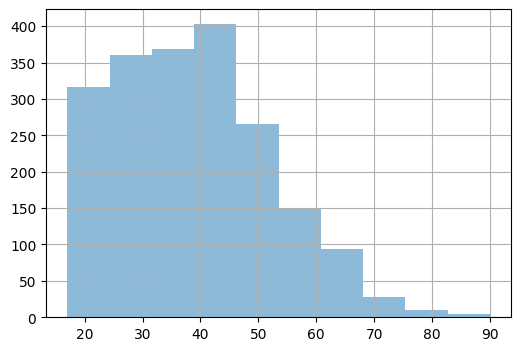

In [4]:
import matplotlib.pyplot as plt

cols = ["age", "education-num", "fnlwgt"]

for col in cols:
    plt.figure(figsize=(6,4))
    real[col].hist(alpha=0.5, label="Real")
    fake[col].hist(alpha=0.5, label="Fake")
    plt.title(f"Distribution comparison: {col}")
    plt.legend()
    plt.show()


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Example: assume last column is label
X_real, y_real = real.iloc[:, :-1], real.iloc[:, -1]
X_fake, y_fake = fake.iloc[:, :-1], fake.iloc[:, -1]

# Train on fake, test on real
clf = RandomForestClassifier()
clf.fit(X_fake, y_fake)
y_pred = clf.predict(X_real)

print("Accuracy when training on fake and testing on real:", accuracy_score(y_real, y_pred))


Accuracy when training on fake and testing on real: 0.0045
